In [2]:
# 08 - Location Intelligence

## Mumbai House Price Prediction & Property Intelligence System

This notebook performs geographic and locality-level analysis of Mumbai properties.

### Objectives:
1. Analyze property latitude and longitude
2. Study locality-wise property distribution
3. Analyze locality-wise average and median prices
4. Analyze price per square foot by locality
5. Visualize property locations geographically
6. Create interactive Mumbai property maps using Folium
7. Create locality-level interactive maps
8. Create property density heatmaps
9. Save maps for future Flask integration

SyntaxError: invalid syntax (542527939.py, line 5)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import os

from folium.plugins import HeatMap

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv("../data/processed/mumbai_house_price_cleaned.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (51767, 14)


,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.244410,73.123253
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.257294,73.148872
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.209026,73.081276
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.097841,72.851158
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.420601,72.809319


In [5]:
property_intelligence = pd.read_csv(
    "../data/processed/property_intelligence.csv"
)

print("Property intelligence dataset loaded.")
print("Shape:", property_intelligence.shape)

property_intelligence.head()

Property intelligence dataset loaded.
Shape: (51767, 22)


,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,...,latitude,longitude,predicted_price,price_difference,price_difference_percent,predicted_price_per_sqft,price_per_sqft_difference,anomaly_label,anomaly_score,is_anomaly
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,...,19.244410,73.123253,5.749573e+06,8.507096e+05,14.796047,7595.209299,1123.790701,1,0.261409,False
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,...,19.257294,73.148872,6.422073e+06,-2.522321e+05,-3.927581,9849.805444,-386.859125,1,0.257219,False
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,...,19.209026,73.081276,4.378319e+06,2.216174e+05,5.061702,11056.360025,559.639975,1,0.242774,False
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,...,19.097841,72.851158,5.084753e+07,1.132471e+06,2.227190,44997.813310,1002.186690,1,0.214435,False
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,...,19.420601,72.809319,3.663747e+06,2.512535e+05,6.857829,8422.405793,577.594207,1,0.208075,False


In [6]:
print("Cleaned Dataset Columns:")
print(df.columns.tolist())

print("\nProperty Intelligence Columns:")
print(property_intelligence.columns.tolist())

Cleaned Dataset Columns:
['price', 'area', 'price_per_sqft', 'locality', 'city', 'property_type', 'bedroom_num', 'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors', 'latitude', 'longitude']

Property Intelligence Columns:
['price', 'area', 'price_per_sqft', 'locality', 'city', 'property_type', 'bedroom_num', 'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors', 'latitude', 'longitude', 'predicted_price', 'price_difference', 'price_difference_percent', 'predicted_price_per_sqft', 'price_per_sqft_difference', 'anomaly_label', 'anomaly_score', 'is_anomaly']


In [7]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (51767, 14)

Data Types:
price               int64
area                int64
price_per_sqft    float64
locality              str
city                  str
property_type         str
bedroom_num         int64
bathroom_num        int64
balcony_num         int64
furnished             str
age                 int64
total_floors        int64
latitude          float64
longitude         float64
dtype: object


In [8]:
print("Missing Latitude:", df["latitude"].isnull().sum())
print("Missing Longitude:", df["longitude"].isnull().sum())

Missing Latitude: 0
Missing Longitude: 0


In [9]:
print("Latitude Statistics:")
print(df["latitude"].describe())

print("\nLongitude Statistics:")
print(df["longitude"].describe())

Latitude Statistics:
count    51767.000000
mean        19.172944
std          0.532951
min         12.889899
25%         19.069774
50%         19.160484
75%         19.228041
max         72.868339
Name: latitude, dtype: float64

Longitude Statistics:
count    51767.000000
mean        72.966697
std          0.457737
min         72.435379
25%         72.856712
50%         72.913185
75%         73.021202
max         91.804413
Name: longitude, dtype: float64


In [10]:
invalid_latitude = (
    (df["latitude"] < -90) |
    (df["latitude"] > 90)
).sum()

invalid_longitude = (
    (df["longitude"] < -180) |
    (df["longitude"] > 180)
).sum()

print("Invalid latitude values:", invalid_latitude)
print("Invalid longitude values:", invalid_longitude)

Invalid latitude values: 0
Invalid longitude values: 0


In [11]:
geo_df = df.copy()

geo_df = geo_df.dropna(
    subset=["latitude", "longitude"]
)

geo_df = geo_df[
    (geo_df["latitude"] >= -90) &
    (geo_df["latitude"] <= 90) &
    (geo_df["longitude"] >= -180) &
    (geo_df["longitude"] <= 180)
].copy()

print("Geographic dataset shape:", geo_df.shape)

geo_df.head()

Geographic dataset shape: (51767, 14)


,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.244410,73.123253
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.257294,73.148872
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.209026,73.081276
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.097841,72.851158
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.420601,72.809319


In [12]:
print("Number of properties with valid coordinates:", len(geo_df))

print("\nLatitude range:")
print(geo_df["latitude"].min(), "to", geo_df["latitude"].max())

print("\nLongitude range:")
print(geo_df["longitude"].min(), "to", geo_df["longitude"].max())

Number of properties with valid coordinates: 51767

Latitude range:
12.88989925 to 72.868338764079

Longitude range:
72.43537903 to 91.80441284


In [13]:
map_latitude = geo_df["latitude"].mean()
map_longitude = geo_df["longitude"].mean()

print("Map Center Latitude:", map_latitude)
print("Map Center Longitude:", map_longitude)

Map Center Latitude: 19.172944319821305
Map Center Longitude: 72.96669689324692


In [14]:
locality_stats = (
    geo_df.groupby("locality")
    .agg(
        listing_count=("locality", "size"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
        average_price_per_sqft=("price_per_sqft", "mean"),
        average_latitude=("latitude", "mean"),
        average_longitude=("longitude", "mean")
    )
    .reset_index()
)

locality_stats.head()

,locality,listing_count,average_price,median_price,average_price_per_sqft,average_latitude,average_longitude
0,Acc Cement Road,1,10000000.0,10000000.0,15037.593985,19.180456,72.958420
1,Adarsh Nagar,2,106093750.0,106093750.0,72716.346154,19.014942,72.821365
2,Additional M.I.D.C,2,3400000.0,3400000.0,4236.955187,19.187177,73.191494
3,Adharwadi,2,3173000.0,3173000.0,7277.669903,19.252434,73.125969
4,Agasan Village,2,30850000.0,30850000.0,31148.284314,19.046006,72.943802


In [15]:
top_localities_count = (
    locality_stats
    .sort_values("listing_count", ascending=False)
    .head(20)
)

top_localities_count

,locality,listing_count,average_price,median_price,average_price_per_sqft,average_latitude,average_longitude
363,Thane,5292,1.575273e+07,12600000.0,15598.323459,19.237083,72.999361
209,Mira Road,3162,8.756489e+06,7900000.0,11339.034222,19.290011,72.883357
142,Kandivali,2039,1.896827e+07,16000000.0,21087.237542,19.231631,72.885014
15,Andheri,2039,3.217703e+07,22863570.0,27220.837746,19.168677,72.908102
160,Kharghar,1904,1.394416e+07,12131200.0,11417.045883,19.078847,73.092187
85,Dombivali,1872,6.019099e+06,5370000.0,8231.365309,19.209209,73.104874
138,Kalyan,1738,6.488894e+06,5250000.0,7660.306629,19.248939,73.148801
46,Borivali,1678,2.102899e+07,17481845.0,23526.606611,19.227277,72.856635
58,Chembur,1591,2.372807e+07,18803016.0,23907.272463,19.073052,72.916680
193,Malad,1522,1.938056e+07,16899777.5,20924.351756,19.196846,72.877535


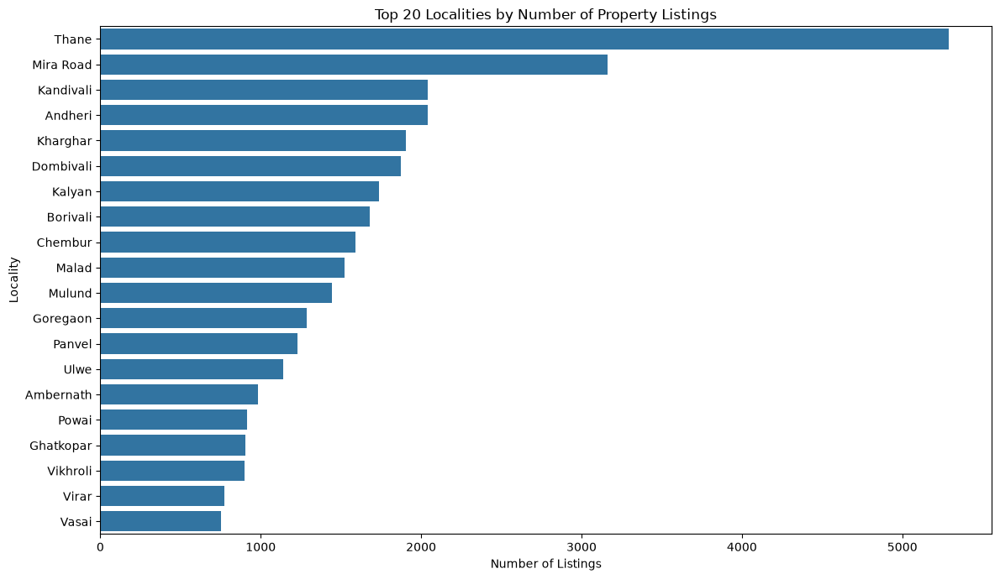

In [16]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_localities_count,
    x="listing_count",
    y="locality"
)

plt.title("Top 20 Localities by Number of Property Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Locality")
plt.tight_layout()
plt.show()

In [17]:
reliable_localities = locality_stats[
    locality_stats["listing_count"] >= 30
].copy()

print(
    "Number of reliable localities:",
    len(reliable_localities)
)

reliable_localities.head()

Number of reliable localities: 87


,locality,listing_count,average_price,median_price,average_price_per_sqft,average_latitude,average_longitude
5,Agripada,40,3.854632e+07,28000000.0,28420.674294,19.026414,72.840731
6,Airoli,240,1.341590e+07,13000000.0,13772.108755,19.154944,72.994974
9,Ambernath,981,3.376406e+06,3100000.0,4667.573477,19.221858,73.216386
15,Andheri,2039,3.217703e+07,22863570.0,27220.837746,19.168677,72.908102
16,Anjurdive,77,7.521017e+06,7500000.0,10068.375657,19.231420,73.039584


In [18]:
top_price_localities = (
    reliable_localities
    .sort_values("average_price", ascending=False)
    .head(20)
)

top_price_localities[
    [
        "locality",
        "listing_count",
        "average_price",
        "median_price"
    ]
]

,locality,listing_count,average_price,median_price
192,Malabar Hill,36,2.811580e+08,122500000.0
202,Marine Lines,33,1.437040e+08,75000000.0
404,Worli,188,1.303466e+08,82082429.5
359,Tardeo,76,1.302058e+08,90000000.0
128,Juhu,179,1.283433e+08,100000000.0
66,Colaba,46,1.275570e+08,46000000.0
275,Prabhadevi,208,8.957243e+07,65000000.0
188,Mahalaxmi,165,8.716537e+07,75000000.0
157,Khar,136,8.228774e+07,60732650.0
184,Lower Parel,349,8.091012e+07,67064600.0


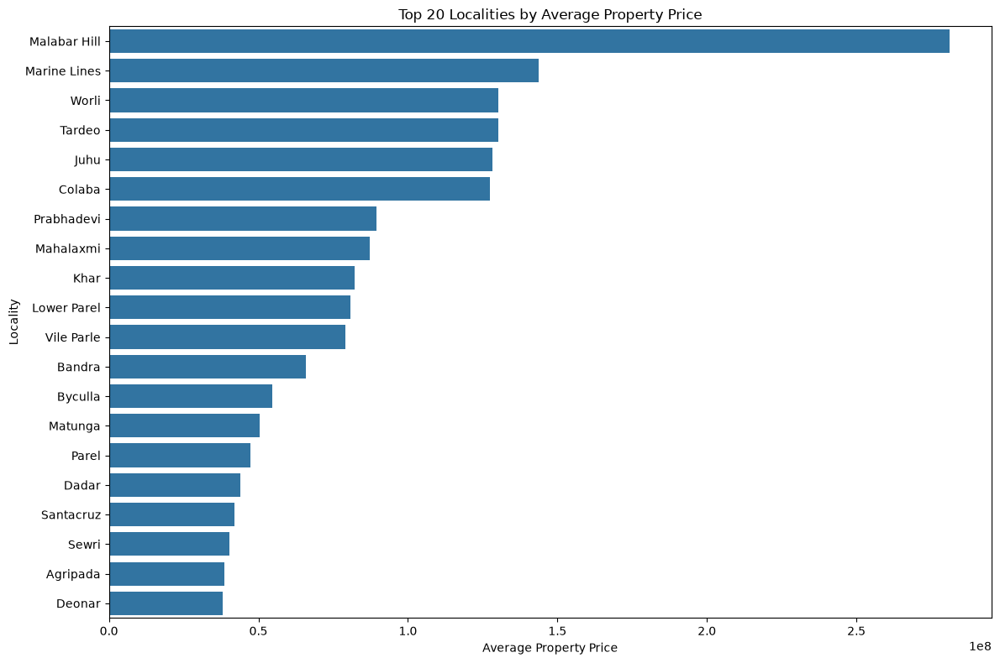

In [19]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_price_localities,
    x="average_price",
    y="locality"
)

plt.title("Top 20 Localities by Average Property Price")
plt.xlabel("Average Property Price")
plt.ylabel("Locality")
plt.tight_layout()
plt.show()

In [20]:
top_median_localities = (
    reliable_localities
    .sort_values("median_price", ascending=False)
    .head(20)
)

top_median_localities[
    [
        "locality",
        "listing_count",
        "median_price"
    ]
]

,locality,listing_count,median_price
192,Malabar Hill,36,122500000.0
128,Juhu,179,100000000.0
359,Tardeo,76,90000000.0
404,Worli,188,82082429.5
202,Marine Lines,33,75000000.0
398,Vile Parle,126,75000000.0
188,Mahalaxmi,165,75000000.0
184,Lower Parel,349,67064600.0
275,Prabhadevi,208,65000000.0
157,Khar,136,60732650.0


In [21]:
top_ppsf_localities = (
    reliable_localities
    .sort_values(
        "average_price_per_sqft",
        ascending=False
    )
    .head(20)
)

top_ppsf_localities[
    [
        "locality",
        "listing_count",
        "average_price_per_sqft"
    ]
]

,locality,listing_count,average_price_per_sqft
192,Malabar Hill,36,76152.100253
359,Tardeo,76,59293.429308
66,Colaba,46,52237.309777
275,Prabhadevi,208,51853.293201
404,Worli,188,51566.333957
128,Juhu,179,51350.437902
188,Mahalaxmi,165,49787.340591
202,Marine Lines,33,47882.013298
184,Lower Parel,349,47436.605820
157,Khar,136,46716.150527


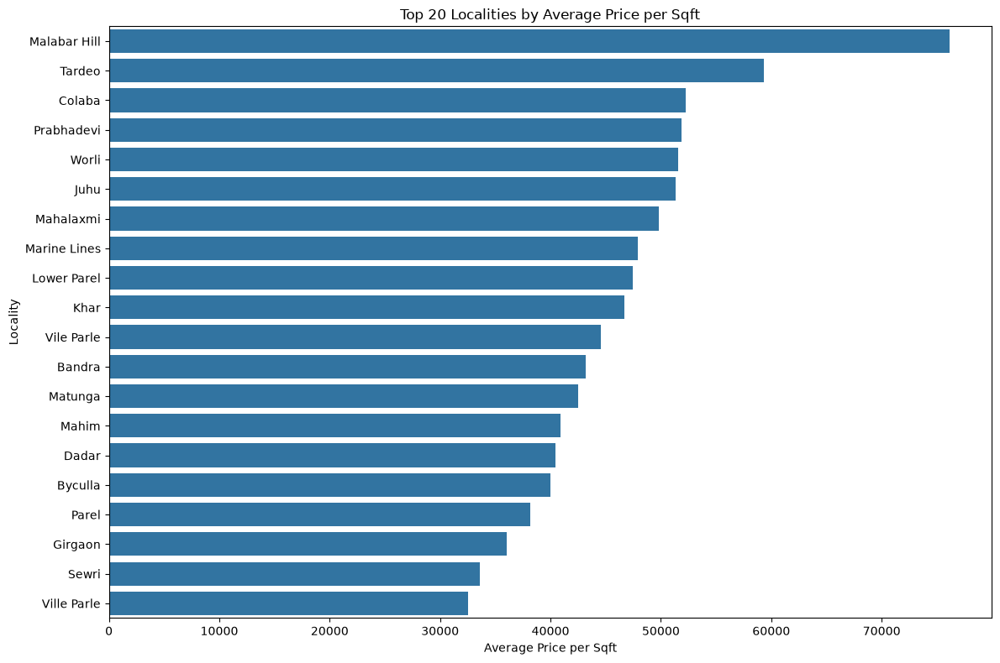

In [22]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_ppsf_localities,
    x="average_price_per_sqft",
    y="locality"
)

plt.title("Top 20 Localities by Average Price per Sqft")
plt.xlabel("Average Price per Sqft")
plt.ylabel("Locality")
plt.tight_layout()
plt.show()

In [23]:
locality_summary = reliable_localities[
    [
        "locality",
        "listing_count",
        "average_price",
        "median_price",
        "average_price_per_sqft",
        "average_latitude",
        "average_longitude"
    ]
].sort_values(
    "listing_count",
    ascending=False
)

locality_summary.head(30)

,locality,listing_count,average_price,median_price,average_price_per_sqft,average_latitude,average_longitude
363,Thane,5292,1.575273e+07,12600000.0,15598.323459,19.237083,72.999361
209,Mira Road,3162,8.756489e+06,7900000.0,11339.034222,19.290011,72.883357
15,Andheri,2039,3.217703e+07,22863570.0,27220.837746,19.168677,72.908102
142,Kandivali,2039,1.896827e+07,16000000.0,21087.237542,19.231631,72.885014
160,Kharghar,1904,1.394416e+07,12131200.0,11417.045883,19.078847,73.092187
85,Dombivali,1872,6.019099e+06,5370000.0,8231.365309,19.209209,73.104874
138,Kalyan,1738,6.488894e+06,5250000.0,7660.306629,19.248939,73.148801
46,Borivali,1678,2.102899e+07,17481845.0,23526.606611,19.227277,72.856635
58,Chembur,1591,2.372807e+07,18803016.0,23907.272463,19.073052,72.916680
193,Malad,1522,1.938056e+07,16899777.5,20924.351756,19.196846,72.877535


Location intelligence saved successfully.


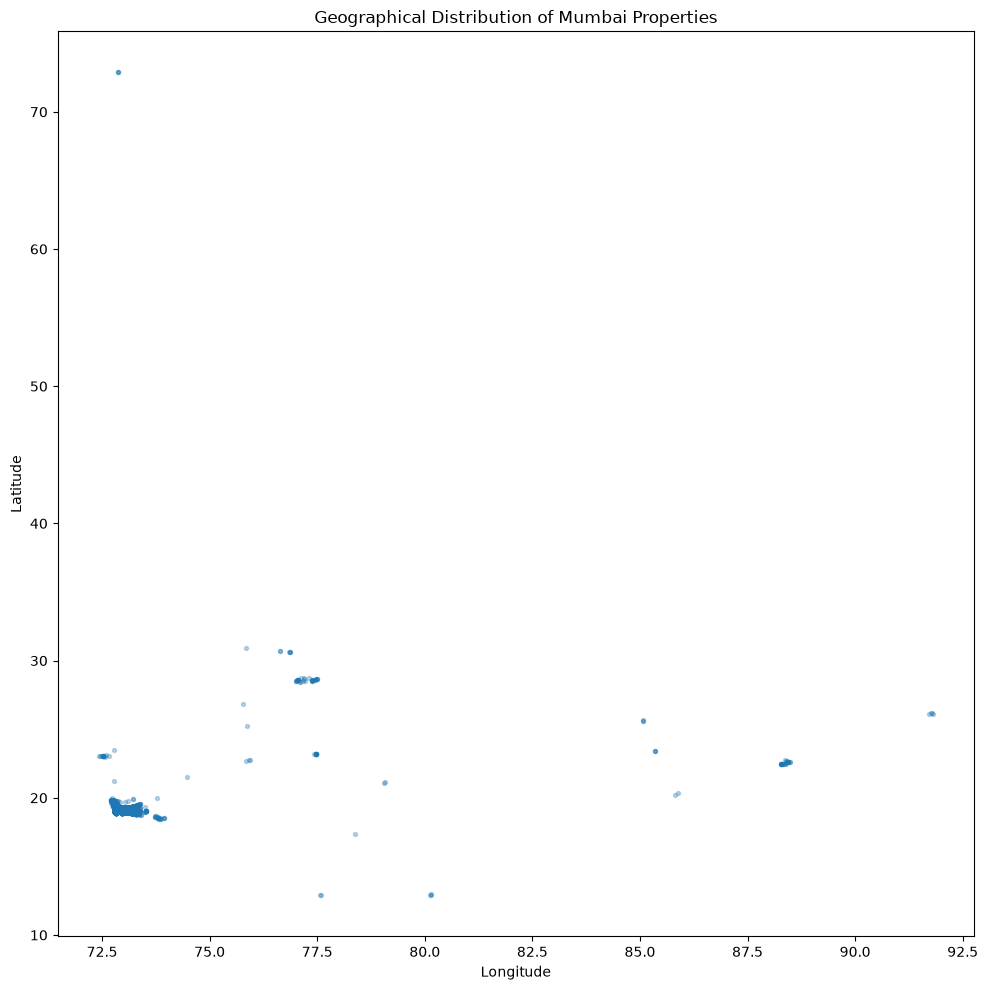

In [24]:
locality_summary.to_csv(
    "../data/processed/location_intelligence.csv",
    index=False
)

print("Location intelligence saved successfully.")
plt.figure(figsize=(10, 10))

plt.scatter(
    geo_df["longitude"],
    geo_df["latitude"],
    alpha=0.3,
    s=8
)

plt.title("Geographical Distribution of Mumbai Properties")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()


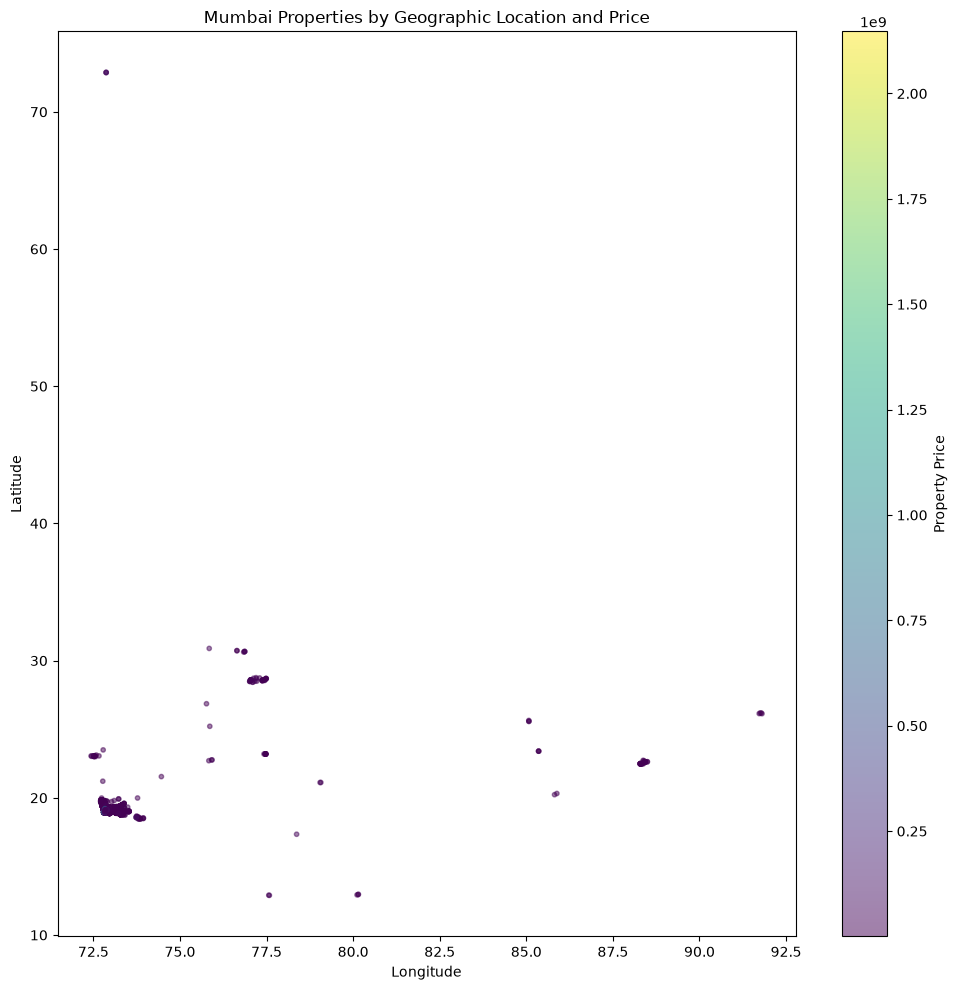

In [25]:
plt.figure(figsize=(10, 10))

scatter = plt.scatter(
    geo_df["longitude"],
    geo_df["latitude"],
    c=geo_df["price"],
    cmap="viridis",
    alpha=0.5,
    s=10
)

plt.colorbar(
    scatter,
    label="Property Price"
)

plt.title("Mumbai Properties by Geographic Location and Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

In [26]:
map_sample_size = min(5000, len(geo_df))

map_df = geo_df.sample(
    n=map_sample_size,
    random_state=42
).copy()

print("Properties used for interactive map:", len(map_df))

Properties used for interactive map: 5000


In [27]:
mumbai_map = folium.Map(
    location=[
        map_latitude,
        map_longitude
    ],
    zoom_start=11,
    tiles="OpenStreetMap"
)

print("Base map created.")

Base map created.


In [28]:
for _, row in map_df.iterrows():

    popup_text = f"""
    <b>Locality:</b> {row.get('locality', 'Unknown')}<br>
    <b>Property Type:</b> {row.get('property_type', 'Unknown')}<br>
    <b>Area:</b> {row.get('area', 'Unknown')} sqft<br>
    <b>Bedrooms:</b> {row.get('bedroom_num', 'Unknown')}<br>
    <b>Bathrooms:</b> {row.get('bathroom_num', 'Unknown')}<br>
    <b>Price:</b> ₹{row.get('price', 0):,.0f}<br>
    <b>Price/Sqft:</b> ₹{row.get('price_per_sqft', 0):,.0f}
    """

    folium.CircleMarker(
        location=[
            row["latitude"],
            row["longitude"]
        ],
        radius=3,
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(
            popup_text,
            max_width=300
        )
    ).add_to(mumbai_map)

print("Property markers added.")

Property markers added.


In [29]:
mumbai_map

In [30]:
property_map_path = (
    "../data/processed/mumbai_property_map.html"
)

mumbai_map.save(property_map_path)

print("Property map saved at:")
print(property_map_path)

Property map saved at:
../data/processed/mumbai_property_map.html


In [31]:
locality_map = folium.Map(
    location=[
        map_latitude,
        map_longitude
    ],
    zoom_start=11,
    tiles="OpenStreetMap"
)

print("Locality map created.")

Locality map created.


In [32]:
for _, row in reliable_localities.iterrows():

    popup_text = f"""
    <b>Locality:</b> {row['locality']}<br>
    <b>Listings:</b> {row['listing_count']}<br>
    <b>Average Price:</b> ₹{row['average_price']:,.0f}<br>
    <b>Median Price:</b> ₹{row['median_price']:,.0f}<br>
    <b>Average Price/Sqft:</b> ₹{row['average_price_per_sqft']:,.0f}
    """

    folium.CircleMarker(
        location=[
            row["average_latitude"],
            row["average_longitude"]
        ],
        radius=max(
            5,
            min(20, row["listing_count"] / 10)
        ),
        popup=folium.Popup(
            popup_text,
            max_width=300
        ),
        fill=True,
        fill_opacity=0.7
    ).add_to(locality_map)

print("Locality markers added.")

Locality markers added.


In [33]:
locality_map

In [34]:
locality_map_path = (
    "../data/processed/mumbai_locality_map.html"
)

locality_map.save(locality_map_path)

print("Locality map saved at:")
print(locality_map_path)

Locality map saved at:
../data/processed/mumbai_locality_map.html


In [35]:
heatmap_data = (
    geo_df[
        ["latitude", "longitude"]
    ]
    .dropna()
)

heatmap_sample_size = min(
    10000,
    len(heatmap_data)
)

heatmap_sample = heatmap_data.sample(
    n=heatmap_sample_size,
    random_state=42
)

heatmap_coordinates = (
    heatmap_sample[
        ["latitude", "longitude"]
    ]
    .values
    .tolist()
)

print(
    "Heatmap points:",
    len(heatmap_coordinates)
)

Heatmap points: 10000


In [36]:
property_heatmap = folium.Map(
    location=[
        map_latitude,
        map_longitude
    ],
    zoom_start=11,
    tiles="OpenStreetMap"
)

HeatMap(
    heatmap_coordinates,
    radius=10,
    blur=15,
    min_opacity=0.3
).add_to(property_heatmap)

print("Property density heatmap created.")

Property density heatmap created.


In [37]:
property_heatmap

In [38]:
heatmap_path = (
    "../data/processed/property_density_heatmap.html"
)

property_heatmap.save(heatmap_path)

print("Heatmap saved at:")
print(heatmap_path)

Heatmap saved at:
../data/processed/property_density_heatmap.html


In [39]:
locality_geo_analysis = reliable_localities[
    [
        "locality",
        "listing_count",
        "average_price",
        "median_price",
        "average_price_per_sqft",
        "average_latitude",
        "average_longitude"
    ]
].copy()

locality_geo_analysis.head(20)

,locality,listing_count,average_price,median_price,average_price_per_sqft,average_latitude,average_longitude
5,Agripada,40,3.854632e+07,28000000.0,28420.674294,19.026414,72.840731
6,Airoli,240,1.341590e+07,13000000.0,13772.108755,19.154944,72.994974
9,Ambernath,981,3.376406e+06,3100000.0,4667.573477,19.221858,73.216386
15,Andheri,2039,3.217703e+07,22863570.0,27220.837746,19.168677,72.908102
16,Anjurdive,77,7.521017e+06,7500000.0,10068.375657,19.231420,73.039584
26,Badlapur,471,2.978721e+06,2600000.0,4186.400175,19.192935,73.289839
28,Bandra,708,6.574589e+07,54694960.0,43222.402936,19.060124,72.843347
33,Belapur,92,2.117290e+07,19750000.0,15537.468868,19.016558,73.035651
37,Bhandup,673,1.298486e+07,11000000.0,17366.505914,19.157158,72.958386
38,Bhayandar,411,8.421125e+06,7565000.0,10632.193303,19.293216,72.865621


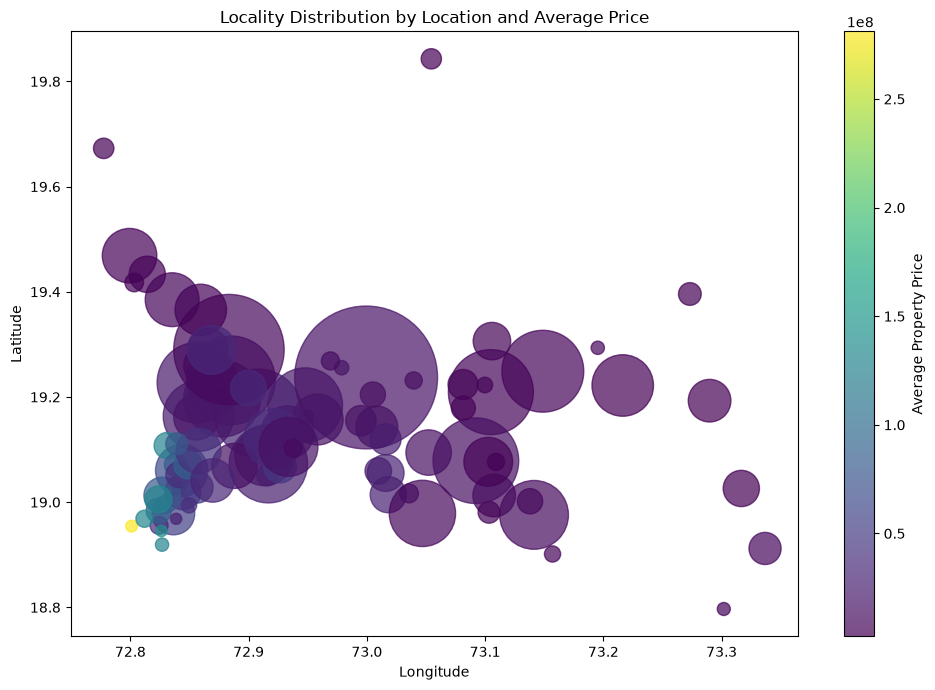

In [40]:
plt.figure(figsize=(10, 7))

plt.scatter(
    locality_geo_analysis["average_longitude"],
    locality_geo_analysis["average_latitude"],
    s=locality_geo_analysis["listing_count"] * 2,
    c=locality_geo_analysis["average_price"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(
    label="Average Property Price"
)

plt.title(
    "Locality Distribution by Location and Average Price"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

In [41]:
top_10_localities = (
    reliable_localities
    .sort_values(
        "listing_count",
        ascending=False
    )
    .head(10)
)

top_10_localities[
    [
        "locality",
        "listing_count",
        "average_price",
        "median_price",
        "average_price_per_sqft"
    ]
]

,locality,listing_count,average_price,median_price,average_price_per_sqft
363,Thane,5292,1.575273e+07,12600000.0,15598.323459
209,Mira Road,3162,8.756489e+06,7900000.0,11339.034222
15,Andheri,2039,3.217703e+07,22863570.0,27220.837746
142,Kandivali,2039,1.896827e+07,16000000.0,21087.237542
160,Kharghar,1904,1.394416e+07,12131200.0,11417.045883
85,Dombivali,1872,6.019099e+06,5370000.0,8231.365309
138,Kalyan,1738,6.488894e+06,5250000.0,7660.306629
46,Borivali,1678,2.102899e+07,17481845.0,23526.606611
58,Chembur,1591,2.372807e+07,18803016.0,23907.272463
193,Malad,1522,1.938056e+07,16899777.5,20924.351756


In [42]:
comparison_df = top_10_localities[
    [
        "locality",
        "average_price",
        "median_price"
    ]
].copy()

comparison_df

,locality,average_price,median_price
363,Thane,1.575273e+07,12600000.0
209,Mira Road,8.756489e+06,7900000.0
15,Andheri,3.217703e+07,22863570.0
142,Kandivali,1.896827e+07,16000000.0
160,Kharghar,1.394416e+07,12131200.0
85,Dombivali,6.019099e+06,5370000.0
138,Kalyan,6.488894e+06,5250000.0
46,Borivali,2.102899e+07,17481845.0
58,Chembur,2.372807e+07,18803016.0
193,Malad,1.938056e+07,16899777.5


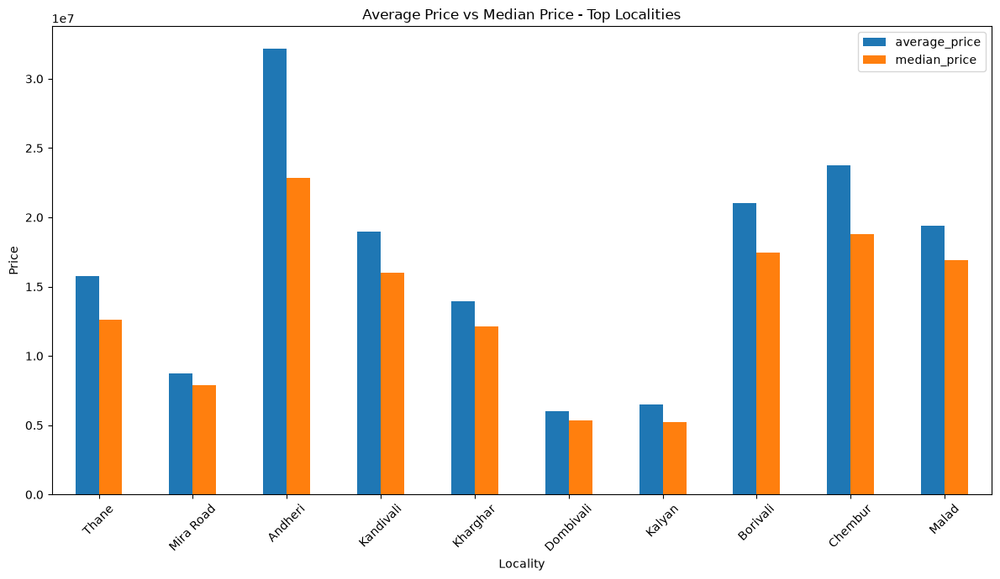

In [43]:
comparison_plot = comparison_df.set_index(
    "locality"
)

comparison_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Average Price vs Median Price - Top Localities"
)

plt.xlabel("Locality")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [44]:
output_files = [
    "../data/processed/location_intelligence.csv",
    "../data/processed/mumbai_property_map.html",
    "../data/processed/mumbai_locality_map.html",
    "../data/processed/property_density_heatmap.html"
]

for file_path in output_files:

    print(
        file_path,
        "->",
        "EXISTS" if os.path.exists(file_path)
        else "NOT FOUND"
    )
    

../data/processed/location_intelligence.csv -> EXISTS
../data/processed/mumbai_property_map.html -> EXISTS
../data/processed/mumbai_locality_map.html -> EXISTS
../data/processed/property_density_heatmap.html -> EXISTS


In [45]:
print("=" * 60)
print("LOCATION INTELLIGENCE COMPLETED")
print("=" * 60)

print("\nTotal properties:", len(df))
print("Properties with valid coordinates:", len(geo_df))
print("Number of localities:", df["locality"].nunique())
print("Reliable localities (30+ listings):", len(reliable_localities))

print("\nGenerated files:")
print("1. location_intelligence.csv")
print("2. mumbai_property_map.html")
print("3. mumbai_locality_map.html")
print("4. property_density_heatmap.html")

print("\nNext step:")
print("Use this location intelligence in the Flask web application.")

LOCATION INTELLIGENCE COMPLETED

Total properties: 51767
Properties with valid coordinates: 51767
Number of localities: 408
Reliable localities (30+ listings): 87

Generated files:
1. location_intelligence.csv
2. mumbai_property_map.html
3. mumbai_locality_map.html
4. property_density_heatmap.html

Next step:
Use this location intelligence in the Flask web application.
